## LAION Memorized

### Setup environment

In [15]:
import sys, os, importlib
print(sys.path)

PATH_ROOT    = "/root/workspace/Python/flipd/"
PATH_MODEL   = "/root/workspace/Python/flipd/notebooks/outputs/notebooks/"
PATH_DATASET = "/root/workspace/Python/flipd/notebooks/dataset/LAION_memorized/"
PATH_FIG   = "/root/workspace/Python/flipd/notebooks/figs/"

os.chdir(PATH_ROOT)
!pwd

['/root/workspace/Python/flipd/notebooks', '/opt/conda/lib/python310.zip', '/opt/conda/lib/python3.10', '/opt/conda/lib/python3.10/lib-dynload', '', '/opt/conda/lib/python3.10/site-packages', '/opt/conda/lib/python3.10/site-packages/setuptools/_vendor']
/root/workspace/Python/flipd


### Load data

In [55]:
import torch
from functools import partial
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

from models.diffusions.stable import (
    StableDiffusionSde,
    StableDiffusionEncoder,
    StableDiffusionDecoder,
)
import importlib
import data.datasets.laion as laion
importlib.reload(laion)
from data.datasets.laion import LAIONMemorized

from lid.diffusions.local_hessian_spectrum import (
    LocalHessianSpectralEstimator, VPSchedule, VESchedule
)

device = torch.device("cuda:1")

sd_sde = StableDiffusionSde().to(device)
sd_encoder = StableDiffusionEncoder(sd_sde.pipeline).to(device)

from torch.utils.data import DataLoader
print("Loading LAIONMemorized...")
# dataset = LAIONMemorized(transform=sd_sde.pipeline.image_processor.preprocess)
# loader = DataLoader(dataset, batch_size=8, shuffle=False, num_workers=4)

from PIL import Image
proc = sd_sde.pipeline.image_processor
def sd_transform(img):
    # SD VAEImageProcessor → [-1,1] tensor
    #return proc.preprocess(img)[0]     # [3,512,512]
    return proc.preprocess(img, height=512, width=512)[0]

In [68]:
dset_mv = LAIONMemorized(mem_type='MV', root_dir=PATH_DATASET, transform=sd_transform)
loader_mv  = DataLoader(dset_mv, batch_size=8, shuffle=False, num_workers=4)

batch = next(iter(loader_mv))
imgs_mv = batch[0].squeeze(1).to(device)    # [B,3,512,512]
caps_mv = batch[1]

with torch.no_grad():
    latents = sd_encoder(imgs_mv)                                    # [B,4,64,64]
flat_latents_mv = latents.view(latents.size(0), -1).contiguous()     # [B, 16384]
print('flat_latents_mv', flat_latents_mv.shape)

debug mem_df: Index(['caption', 'index', 'scores', 'url', 'numdups', 'edge_scores',
       'mse_real_gen', 'overfit_type', 'gen_seeds', 'retrieved_urls'],
      dtype='object')
debug mem_df filtered:                                                  caption       index  \
22716               The No Limits Business Woman Podcast  1030727993   
11426  Full body U-Zip main opening - Full body U-Zip...  2026642560   
16576               Mothers influence on her young hippo   964841345   
954    "Watch: Passion Pit's New Video, ""Lifted Up (...   567947515   
22355          Talks on the Precepts and Buddhist Ethics   455502462   
...                                                  ...         ...   
10575                FUSE Roll Top Backpack 25 - View 61   283006352   
19670             Renegade RSS Laptop Backpack - View 10  1414204477   
24295                  Waterford Sand Silk Stripe Swatch   937045133   
10578                FUSE Roll Top Backpack 25 - View 91  1311057528   
10558   

Loading images: 86it [00:00, 134.34it/s]


flat_latents_mv torch.Size([8, 16384])


In [64]:
dset_n = LAIONMemorized(mem_type='N', root_dir=PATH_DATASET, transform=sd_transform)
loader_n  = DataLoader(dset_n, batch_size=8, shuffle=False, num_workers=4)

batch = next(iter(loader_n))
imgs_n = batch[0].squeeze(1).to(device)    # [B,3,512,512]
caps_n = batch[1]

with torch.no_grad():
    latents = sd_encoder(imgs_n)                                    # [B,4,64,64]
flat_latents_n = latents.view(latents.size(0), -1).contiguous()     # [B, 16384]

debug mem_df: Index(['caption', 'index', 'scores', 'url', 'numdups', 'edge_scores',
       'mse_real_gen', 'overfit_type', 'gen_seeds', 'retrieved_urls'],
      dtype='object')
debug mem_df filtered:                                                  caption       index  \
26136                         email, envelope, mail icon  1730933243   
25877  communication, email, mail, message, online, o...  2137580772   
27018  lock, locked, padlock, protected, protection, ...  1155508791   
406    "3M™ Privacy Filter for 24"" Widescreen Monito...  1953226014   
26082                        document,print,preview icon  1454892847   
...                                                  ...         ...   
18223  Pella 1-panel Insulating Core Full Lite Right-...  1471094273   
4829                 Antarctic ozone map for 12 May 1981  2070526890   
3564   65-inch x 80-inch x 4 9/16-inch Brass 3/4-Lite...  1543139499   
6509   Black and white shot of person walking on deso...   211851841   
18443  P

Loading images: 155it [00:01, 95.29it/s] 


imgs shape: torch.Size([8, 3, 512, 512]) tensor(-1., device='cuda:1') tensor(1., device='cuda:1')


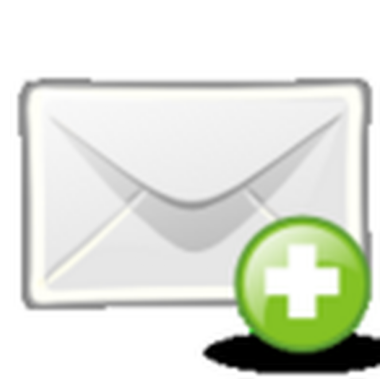

In [65]:
imgs = imgs_n
# show samples
print("imgs shape:", imgs.shape, imgs.min(), imgs.max())
img0 = imgs[0].detach().cpu()           # [3, 512, 512]
# SD latent/image processor often gives [-1,1]; rescale to [0,1]
img0 = (img0 + 1.0) / 2.0               # [0,1]
# Convert to HWC for matplotlib
img0 = img0.permute(1, 2, 0).clamp(0, 1).numpy()  # [512, 512, 3]

plt.imshow(img0)
plt.axis("off")
plt.show()

In [46]:
import torch
import torch.nn as nn

class SDLatentAdapter(nn.Module):
    """
    Wrap Stable Diffusion UNet so that:
      - input:  x [B,D] or [B,4,64,64]
      - input:  t (scalar or [B])
      - output: sigma * score(x,t) = -eps(x,t) as flat [B,D]
    """

    def __init__(self, pipeline, C=4, H=64, W=64, device="cuda"):
        super().__init__()

        self.unet = pipeline.unet
        self.text_encoder = pipeline.text_encoder
        self.tokenizer = pipeline.tokenizer

        self.C, self.H, self.W = C, H, W
        self.D = C * H * W

        # Take device from text_encoder (after pipeline.to(device))
        text_device = next(self.text_encoder.parameters()).device

        tokens = self.tokenizer(
            [""],
            padding="max_length",
            max_length=self.tokenizer.model_max_length,
            return_tensors="pt",
        ).to(text_device)

        with torch.no_grad():
            # CLIP text encoder: returns (last_hidden_state, pooled_output)
            self.uncond_emb = self.text_encoder(tokens.input_ids)[0]  # [1,77,768]

        # keep adapter on same device as pipeline
        self.to(text_device)

    def forward(self, x, t, **kwargs):
        """
        x: [B,D] or [B,4,64,64]
        t: scalar, list, or tensor of timesteps (diffusers indices)
        returns: [B,D] = -eps(x,t)
        """
        device = x.device

        # [B,D] → [B,4,64,64]
        if x.ndim == 2:
            B = x.shape[0]
            x = x.view(B, self.C, self.H, self.W)
        else:
            B = x.size(0)

        # unconditional text embedding
        enc = self.uncond_emb.to(device).repeat(B, 1, 1)

        # normalize t to LongTensor [B]
        if not torch.is_tensor(t):
            t = torch.tensor(t, device=device)
        if t.ndim == 0:
            t = t.expand(B)
        t = t.long().to(device)

        eps = self.unet(
            sample=x,
            timestep=t,
            encoder_hidden_states=enc,
        ).sample  # [B,4,64,64]

        # IMPORTANT: return sigma * score = -eps
        return (-eps).view(B, self.D)


In [38]:
from models.diffusions.sdes import VpSde
from lid.diffusions.local_hessian_spectrum import (
    LocalHessianSpectralEstimator, VPSchedule, VESchedule
)

In [47]:
sd_sde = StableDiffusionSde()  
sd_pipeline = sd_sde.pipeline
sd_pipeline.to(device)    

adapter = SDLatentAdapter(
    pipeline=sd_pipeline,
    C=4, H=64, W=64,
    device=device,
)

from models.diffusions.sdes import VpSde
sd_sde_latent = VpSde(score_net=adapter).to(device)


In [70]:
ambient_dim = 4 * 64 * 64
n_samples   = 500

delta = 0.01
lid_estimator_soft_dof = LocalHessianSpectralEstimator(
    model=sd_sde_latent,
    schedule=VPSchedule(beta_min=0.1, beta_max=20.0),
    method="Soft_DoF",
    ambient_dim=4*64*64,
    device=device,
    batch_size=500
)

flat_latents = flat_latents_mv
# x_latent_flat: [n_samples, 4*64*64] from LAIONMemorized → SD encoder
lid_soft_dof = lid_estimator_soft_dof.estimate_lid(flat_latents.to(device), 
                                                   soft_c=0.1, soft_p=8,
                                                   delta=delta).cpu().numpy()
print(np.mean(lid_soft_dof))


flat_latents = flat_latents_n
# x_latent_flat: [n_samples, 4*64*64] from LAIONMemorized → SD encoder
lid_soft_dof = lid_estimator_soft_dof.estimate_lid(flat_latents.to(device), 
                                                   soft_c=0.1, soft_p=8,
                                                   delta=delta).cpu().numpy()
print(np.mean(lid_soft_dof))

10301.653
1711.8749


In [60]:
import torch
from tqdm import tqdm
import numpy as np

def estimate_lid_laion(lid_estimator,encoder,loader,delta: float,device,max_samples: int | None = None,):
    lids = []
    kept_imgs = []       # list of raw images (CPU tensors)
    seen = 0

    for imgs, _ in tqdm(loader, desc="Estimating LID"):
        if max_samples is not None and seen >= max_samples:
            break

        B = imgs.size(0)

        # handle max_samples cut
        if max_samples is not None and seen + B > max_samples:
            B = max_samples - seen
            imgs = imgs[:B]

        # keep a CPU copy of the original images
        kept_imgs.append(imgs.cpu())          # shape [B,3,512,512] (or whatever transform gives)

        # encode to latents
        with torch.no_grad():
            latents = encoder(imgs.squeeze(1).to(device))  # [B,4,64,64]

        x = latents.view(B, -1).to(device)     # [B,16384]
        x.requires_grad_(True)

        lid_batch = lid_estimator.estimate_lid(x, delta=delta, soft_c=0.5, soft_p=8,)
        lids.append(lid_batch.detach().cpu())

        seen += B

    lids = torch.cat(lids, dim=0).numpy()
    imgs = torch.cat(kept_imgs, dim=0)[:seen]  # keep exactly the number of samples processed
    return lids, imgs


In [73]:
delta = 0.01

lid_soft_dof_mv, imgs_mv = estimate_lid_laion(
    lid_estimator_soft_dof,
    sd_encoder,
    loader_mv,
    delta=delta,
    device=device,
    max_samples=5000,
)
print("mean:", lid_soft_dof_mv.mean(), "std:", lid_soft_dof_mv.std())

lid_soft_dof_n, imgs_n = estimate_lid_laion(
    lid_estimator_soft_dof,
    sd_encoder,
    loader_n,
    delta=delta,
    device=device,
    max_samples=5000,
)
print("mean:", lid_soft_dof_n.mean(), "std:", lid_soft_dof_n.std())


Estimating LID: 100%|██████████| 9/9 [01:06<00:00,  7.38s/it]


mean: 14134.216 std: 1578.2388


Estimating LID: 100%|██████████| 16/16 [02:03<00:00,  7.71s/it]


mean: 11125.309 std: 3932.7131


... saved /root/workspace/Python/flipd/notebooks/figs/LAION_Memorizaed.png


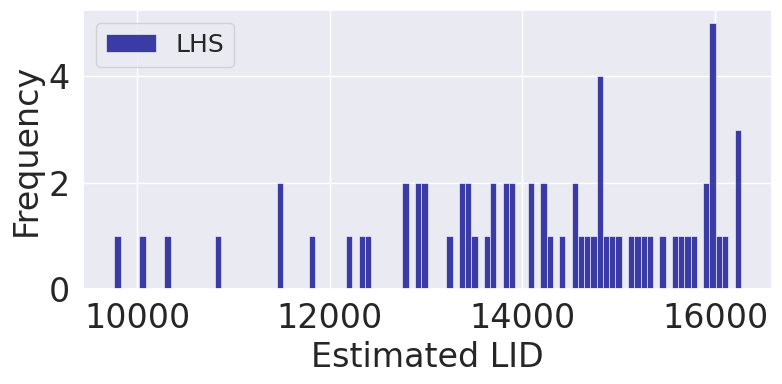

... saved /root/workspace/Python/flipd/notebooks/figs/LAION_Memorizaed.png


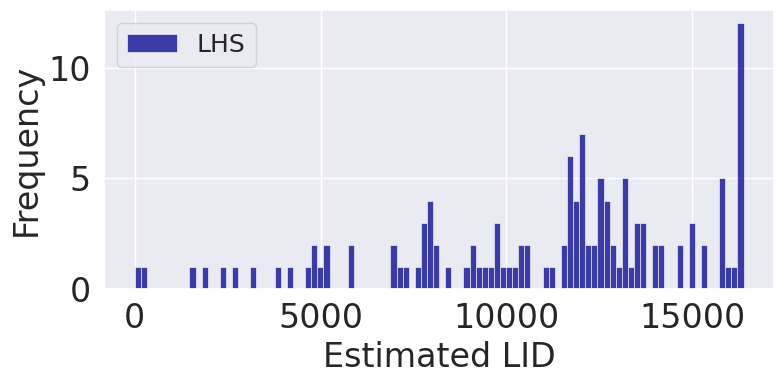

In [74]:
import visualization.notebook_utils as notebook_utils
importlib.reload(notebook_utils)
from visualization.notebook_utils import plot_histograms 

filename = os.path.join(PATH_FIG, "LAION_Memorizaed")
plot_histograms([lid_soft_dof_mv], labels=['LHS'], filename=filename)

plot_histograms([lid_soft_dof_n], labels=['LHS'], filename=filename)


In [ ]:
import numpy as np
import torch

def select_imgs_by_lid(
    imgs: torch.Tensor,
    lids: np.ndarray,
    m: int,
    mode: str = "even",
):
    """
    Select images based on their LID values.

    Args:
        imgs: torch.Tensor (N, C, H, W) — image tensor.
        lids: np.ndarray (N,) — estimated LID values.
        m: int — number of images to pick.
        mode: {'even', 'low', 'high'}
            'even' → evenly spaced across full LID range
            'low'  → lowest m LIDs
            'high' → highest m LIDs

    Returns:
        (imgs_sel, lids_sel, idx_sel)
            imgs_sel: selected image tensor
            lids_sel: corresponding LID numpy array
            idx_sel: selected indices (sorted ascending by LID)
    """
    n = len(lids)
    m = int(min(max(1, m), n))
    lids = np.asarray(lids)
    order = np.argsort(lids)
    lids_sorted = lids[order]

    if mode == "low":
        idx_sel = order[:m]
    elif mode == "high":
        idx_sel = order[-m:]
    elif mode == "even":
        lid_min, lid_max = float(lids_sorted.min()), float(lids_sorted.max())
        if lid_max == lid_min:
            idx_sel = order[np.linspace(0, n - 1, m).round().astype(int)]
        else:
            targets = np.linspace(lid_min, lid_max, m)
            chosen = []
            used = np.zeros(n, dtype=bool)
            for t in targets:
                mask = ~used
                if not mask.any():
                    break
                candidates = np.arange(n)[mask]
                i = candidates[np.argmin(np.abs(lids_sorted[candidates] - t))]
                chosen.append(i)
                used[i] = True
            idx_sel = order[np.sort(np.array(chosen))]
    else:
        raise ValueError(f"Invalid mode '{mode}', must be one of ['even','low','high']")

    # ensure ascending by LID value
    idx_sel = idx_sel[np.argsort(lids[idx_sel])]
    imgs_sel = imgs[idx_sel]
    lids_sel = lids[idx_sel]
    return imgs_sel, lids_sel, idx_sel


In [ ]:
import matplotlib.pyplot as plt
import torch
import os

def show_and_save_images(imgs, lids, save_path=None):
    """
    Display and save selected images ordered by estimated LID.

    Args:
        imgs: torch.Tensor of shape (N, C, H, W)
        lids: numpy array of shape (N,)
        save_path: output file path (PNG recommended)
    """
    n = imgs.size(0)
    cols = min(8, n)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(2.5*cols, 2.5*rows))
    axes = np.array(axes).reshape(rows, cols)

    for i, ax in enumerate(axes.flatten()):
        if i < n:
            img = imgs[i]
            if img.ndim == 3 and img.size(0) in (1, 3):
                img_np = img.permute(1, 2, 0).cpu().numpy()
                if img_np.shape[-1] == 1:
                    img_np = img_np.squeeze(-1)
            else:
                img_np = img.cpu().numpy()
            ax.imshow(img_np, cmap="gray")
            ax.set_title(f"LID={lids[i]:.2f}", fontsize=20)
        ax.axis("off")

    #plt.subplots_adjust(wspace=0.01, hspace=0.01)

    #plt.tight_layout()
    plt.tight_layout(pad=0.0, w_pad=0.0)

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved to {os.path.abspath(save_path)}")
    plt.show()
    

In [ ]:
from data.datasets.laion import LAIONMemorized

# no transform
dataset_raw = LAIONMemorized(transform=None)

img0, cap0 = dataset_raw[0]
print(type(img0), img0)

import matplotlib.pyplot as plt

plt.imshow(img0)
plt.axis("off")

In [ ]:
batch = next(iter(loader))
imgs_raw, _ = batch
print("raw:", imgs_raw.shape, imgs_raw.dtype, imgs_raw.min(), imgs_raw.max())

imgs_s = imgs_raw.squeeze(1)  # [B,3,512,512]
print("squeezed:", imgs_s.shape, imgs_s.min(), imgs_s.max())

In [ ]:
m = 16
imgs = imgs.squeeze(1)
print(torch.min(imgs), torch.max(imgs), imgs)

imgs = (imgs + 1) / 2
imgs = imgs.clamp(0, 1)

imgs_low, lids_low, idx_low = select_imgs_by_lid(imgs, lid_soft_dof, m, mode="low")
imgs_high, lids_high, idx_high = select_imgs_by_lid(imgs, lid_soft_dof, m, mode="high")
imgs_even, lids_even, idx_even = select_imgs_by_lid(imgs, lid_soft_dof, m, mode="even")

show_and_save_images(imgs_low, lids_low, save_path=os.path.join(PATH_FIG, "LIAON_low_lid.png"))
show_and_save_images(imgs_high, lids_high, save_path=os.path.join(PATH_FIG, "LIAON_hign_lid.png"))
show_and_save_images(imgs_even, lids_even, save_path=os.path.join(PATH_FIG, "LIAON_even_lid.png"))

In [ ]:
lid_logistic_dof = lid_estimator_logistic_dof.estimate_lid(flat, delta=delta).cpu().numpy()
print('LogisticDoF:', np.mean(lid_logistic_dof))
plot_histograms([lid_logistic_dof], labels=['LHS'], filename=filename + "_logistic_dof")

## Competitor - Normal Bundle

While the original paper suggests t ~= 0 and the default value of this FLIPD codebase is 1e-4, larger t seems better.

In [ ]:
from lid.diffusions import NormalBundleEstimator
lid_estimator_nb = NormalBundleEstimator(model=vp_sde, ambient_dim=ambient_dim, device=device,)
lid = lid_estimator_nb.estimate_lid(data, noise_time=1e-3).detach().cpu().numpy()
print('NB:', mae(lid, gt_lid))

## Competitor - LIDL

In [ ]:
from lid.diffusions.fokker_planck import FPRegressEstimator
lid_estimator_lidl = FPRegressEstimator(model=vp_sde, ambient_dim=ambient_dim,device=device,)
lid = lid_estimator_lidl.estimate_lid(data, delta=1e-3).detach().cpu().numpy()
print('LIDL:', mae(lid, gt_lid))

## Competitor - FLIPD

In [ ]:
from lid.diffusions.fokker_planck import FlipdEstimator
lid_estimator_flipd = FlipdEstimator(model=vp_sde, ambient_dim=ambient_dim,device=device,)
lid = lid_estimator_flipd.estimate_lid(data).detach().cpu().numpy()
print('FLIPD:', mae(lid, gt_lid))

## Competitor - ESS

In [ ]:
from lid.skdim.skdim import SkdimLIDEstimator
est = SkdimLIDEstimator(data=data, ambient_dim=ambient_dim, estimator_type="ESS")
#est.fit(n_neighbors=20, n_jobs=-1)
est.fit()
lid = est.estimate_lid(data).cpu().numpy()
print('ESS:', mae(lid, gt_lid))

## Competitor - LPCA

In [ ]:
from lid.skdim.skdim import SkdimLIDEstimator
est = SkdimLIDEstimator(data=data, ambient_dim=ambient_dim, estimator_type="lPCA")
#est.fit(n_neighbors=20, n_jobs=-1)
est.fit()
lid = est.estimate_lid(data).cpu().numpy()
print('LPCA:', mae(lid, gt_lid))